In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Advanced Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [33]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_012_health_indicators_BRFSS2015.csv to diabetes_012_health_indicators_BRFSS2015 (1).csv


In [34]:
import pandas as pd

df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [35]:
# checking the dataset's dimensions (`df.shape`), data types and non-null counts (`df.info()`), identifying any missing values (`df.isnull().sum()`), and the distribution of the target variable (`df['Diabetes_012'].value_counts(normalize=True)`), which is crucial for understanding class imbalance.
print("Shape:", df.shape)
df.info()

# Missing values
df.isnull().sum()

# Class distribution
df['Diabetes_012'].value_counts(normalize=True)

Shape: (253680, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non

,proportion
Diabetes_012,
0.0,0.842412
2.0,0.139333
1.0,0.018255


In [36]:
# duplicate rows are removed to ensure data integrity and avoid bias in analysis.
# Remove duplicates
df = df.drop_duplicates()

# Rename target for clarity
df.rename(columns={"Diabetes_012": "target"}, inplace=True)
df.shape

(229781, 22)

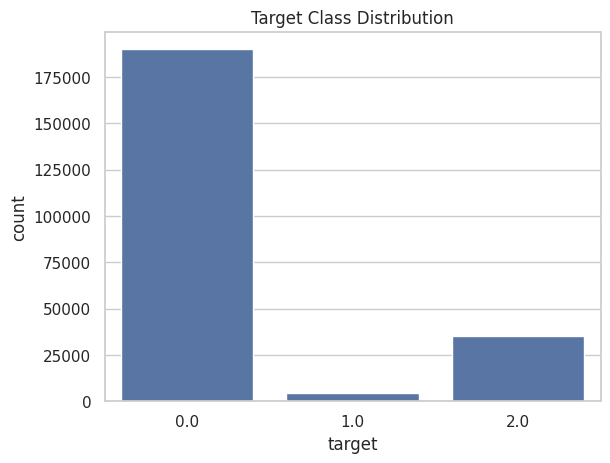

In [37]:
# A count plot visualizes the distribution of the 'target' variable. This confirms the presence of class imbalance (0.0: No Diabetes, 2.0: Diabetes, 1.0: Pre-diabetes), which is important to consider during model selection and evaluation.
sns.countplot(x='target', data=df)
plt.title("Target Class Distribution")
plt.show()

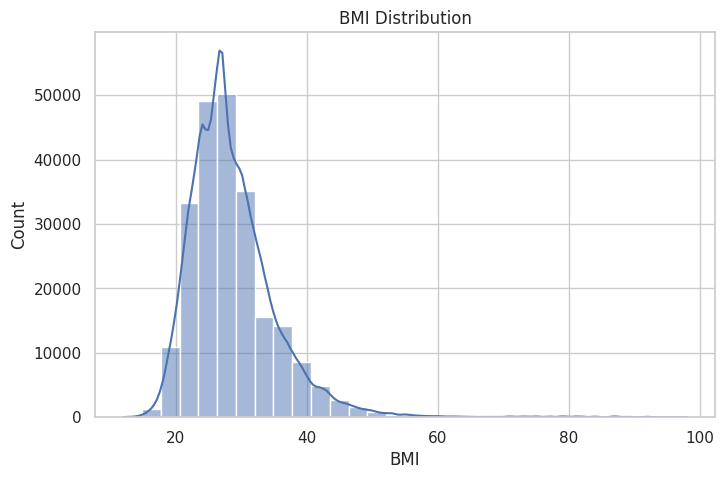

In [38]:
# This histogram displays the distribution of the 'BMI' feature. Understanding the distribution of numerical features like BMI can reveal insights into the population's health status and potential outliers.
plt.figure(figsize=(8,5))
sns.histplot(df['BMI'], bins=30, kde=True)
plt.title("BMI Distribution")
plt.show()

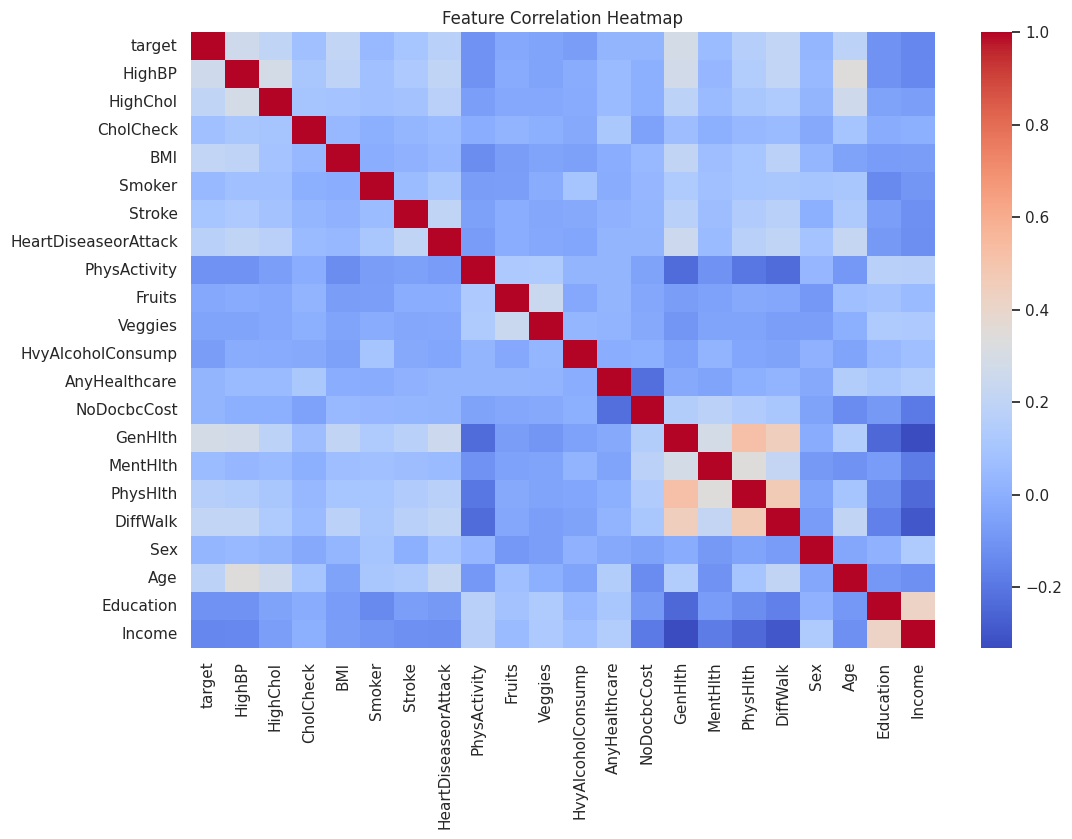

In [39]:
# A correlation heatmap visually represents the linear relationships between all numerical features. This helps identify highly correlated features, which can be useful for feature selection or understanding multicollinearity.
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

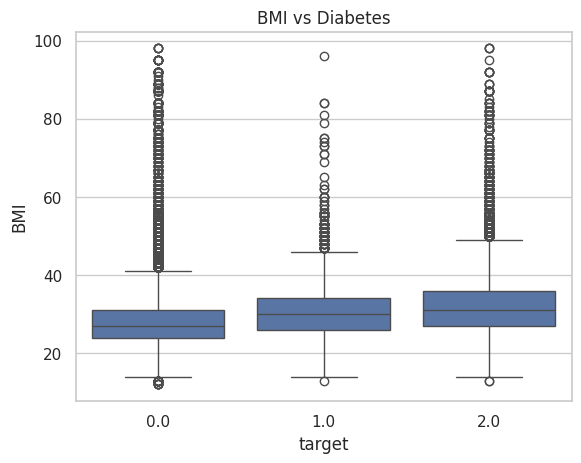

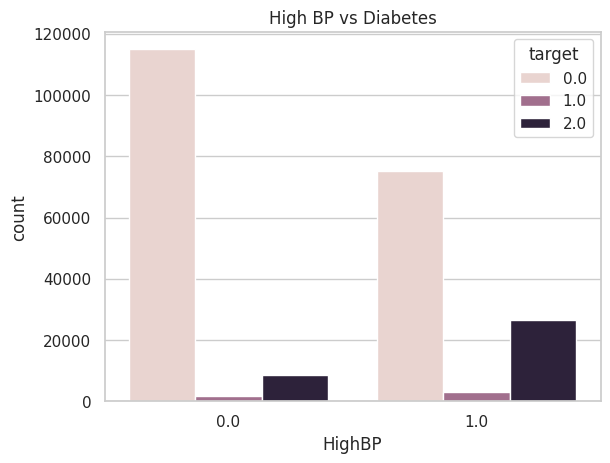

In [40]:
# These plots explore the relationship between key features ('BMI' and 'HighBP') and the 'target' variable. The box plot shows BMI distribution across diabetes categories, while the count plot shows the frequency of high blood pressure for each target class, providing initial insights into potential predictors.
sns.boxplot(x='target', y='BMI', data=df)
plt.title("BMI vs Diabetes")
plt.show()

sns.countplot(x='HighBP', hue='target', data=df)
plt.title("High BP vs Diabetes")
plt.show()

In [41]:
# This cell demonstrates feature engineering by creating new features: `bmi_category` (categorizing BMI into health groups), `age_bmi_interaction` (combining age and BMI for potential synergistic effects), and `lifestyle_score` (a composite score from health-related activities). One-hot encoding is applied to the new `bmi_category` to prepare it for modeling.
# BMI Categories
df['bmi_category'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=[0, 1, 2, 3]
)

# Age interaction
df['age_bmi_interaction'] = df['Age'] * df['BMI']

# Lifestyle score
df['lifestyle_score'] = df['PhysActivity'] + df['Fruits'] + df['Veggies']
df = pd.get_dummies(df, columns=['bmi_category'], drop_first=True)

In [42]:
# The dataset is split into features (X) and target (y). Then, the data is divided into training and testing sets using `train_test_split` with stratification to maintain the target distribution in both sets. `StandardScaler` is applied to normalize numerical features, which is crucial for models sensitive to feature scales like Logistic Regression.
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
# A Logistic Regression model is initialized and trained on the scaled training data.
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)

In [44]:
# A RandomForestClassifier model is initialized and trained on the training data.
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)

In [45]:
# An XGBoost Classifier model is initialized and trained on the training data.
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)

In [46]:
# A LightGBM Classifier model is initialized and trained on the training data.
lgb = LGBMClassifier()
lgb.fit(X_train, y_train)

lgb_preds = lgb.predict(X_test)
lgb_probs = lgb.predict_proba(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 183824, number of used features: 26
[LightGBM] [Info] Start training from score -0.189815
[LightGBM] [Info] Start training from score -3.904835
[LightGBM] [Info] Start training from score -1.878992


In [47]:
# The `evaluate_model` function calculates and prints several key classification metrics (Accuracy, Precision, Recall, F1 Score, ROC-AUC) for each model.
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{name} Performance:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob, multi_class='ovr'))

evaluate_model("Logistic Regression", y_test, lr_preds, lr_probs)
evaluate_model("Random Forest", y_test, rf_preds, rf_probs)
evaluate_model("XGBoost", y_test, xgb_preds, xgb_probs)
evaluate_model("LightGBM", y_test, lgb_preds, lgb_probs)


Logistic Regression Performance:
Accuracy: 0.8343669081967926
Precision: 0.7871759781991701
Recall: 0.8343669081967926
F1 Score: 0.7934540914162629
ROC-AUC: 0.7711156006766462

Random Forest Performance:
Accuracy: 0.8234218943795287
Precision: 0.7733749379400634
Recall: 0.8234218943795287
F1 Score: 0.7873900695173686
ROC-AUC: 0.7206805896890872

XGBoost Performance:
Accuracy: 0.8368257283982854
Precision: 0.7918695625856172
Recall: 0.8368257283982854
F1 Score: 0.797112362697768
ROC-AUC: 0.7662895808998119

LightGBM Performance:
Accuracy: 0.8380442587636269
Precision: 0.7942413542469351
Recall: 0.8380442587636269
F1 Score: 0.7969947178834826
ROC-AUC: 0.7749728573377347


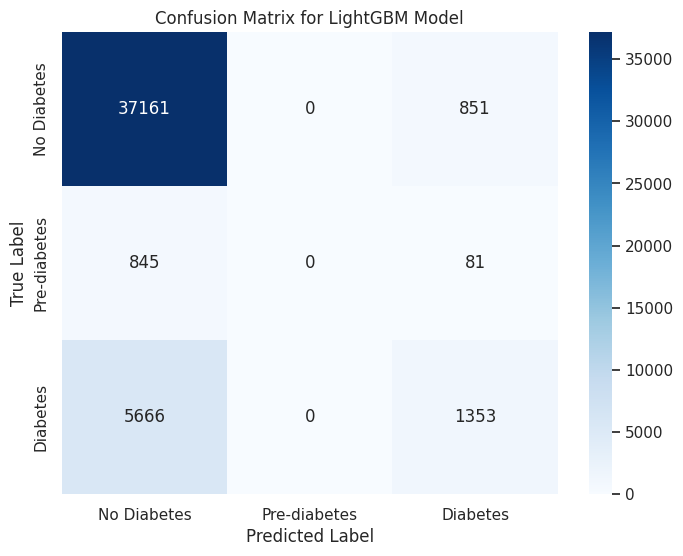

In [48]:
# A confusion matrix for the LightGBM model is plotted. This visualization provides a detailed breakdown of correct and incorrect predictions for each class.
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate confusion matrix for LightGBM
cm = confusion_matrix(y_test, lgb_preds)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Pre-diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Pre-diabetes', 'Diabetes'])
plt.title('Confusion Matrix for LightGBM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [49]:
# This cell calculates and displays the feature importances from the trained LightGBM model. Understanding feature importance helps identify which input variables are most influential in predicting the target.
# Get feature importances from the LightGBM model
feature_importance = lgb.feature_importances_

# Create a DataFrame to store feature names and their importances
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top N most important features
display(importance_df.head(10))

,Feature,Importance
21,age_bmi_interaction,1552
3,BMI,1214
13,GenHlth,732
20,Income,680
15,PhysHlth,648
14,MentHlth,598
18,Age,502
19,Education,440
17,Sex,287
1,HighChol,283


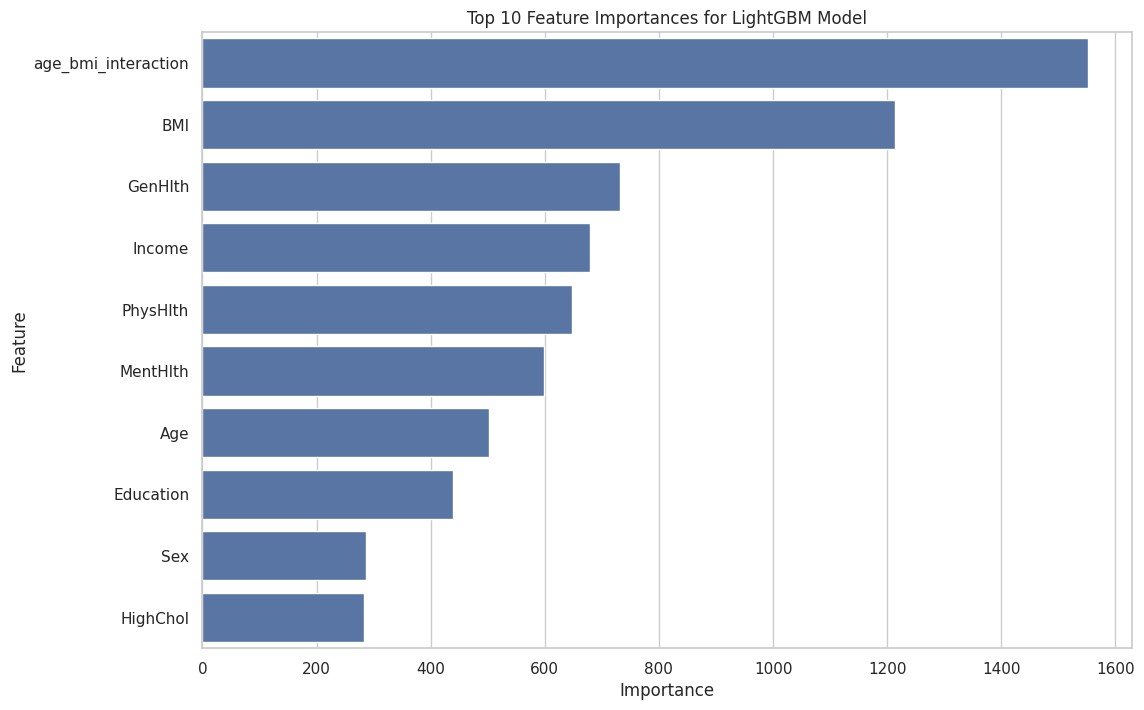

In [50]:
# This bar plot visualizes the top 10 most important features for the LightGBM model.
# Plotting the top 10 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importances for LightGBM Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [51]:
# A DataFrame named `results` is created to summarize the accuracy scores of all trained models. Sorting these results helps to quickly identify the best-performing model based on accuracy, providing a clear overview for comparison.
results = pd.DataFrame({
    "Model": ["Logistic", "Random Forest", "XGBoost", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds),
        accuracy_score(y_test, lgb_preds)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
3,LightGBM,0.838044
2,XGBoost,0.836826
0,Logistic,0.834367
1,Random Forest,0.823422


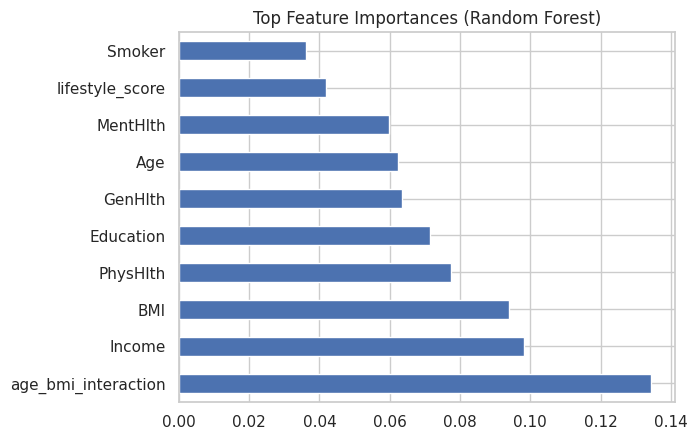

In [52]:
# Similar to LightGBM, this plot shows the top 10 feature importances specifically for the Random Forest model.
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top Feature Importances (Random Forest)")
plt.show()

In [53]:
# This cell implements Stratified K-Fold Cross-Validation for the LightGBM model.
skf = StratifiedKFold(n_splits=5)

scores = []

for train_idx, val_idx in skf.split(X, y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = LGBMClassifier()
    model.fit(X_tr, y_tr)

    preds = model.predict(X_val)
    scores.append(f1_score(y_val, preds, average='weighted'))

print("Cross-Validation F1 Score:", np.mean(scores))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037925 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 183824, number of used features: 26
[LightGBM] [Info] Start training from score -0.189809
[LightGBM] [Info] Start training from score -3.904835
[LightGBM] [Info] Start training from score -1.879028
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036713 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 465
[LightGBM] [Info] Number of data points in the train set: 183825, number of used features: 26
[LightGBM] [Info] Start training from score -0.189814
[LightGBM] [Info] Start training from score -3.904571
[LightGBM] [Info] Start 

In [54]:
# This cell provides a concluding summary of the project, highlighting the key steps taken and the overall findings, such as the superior performance of ensemble models in this healthcare dataset.
print("""
Conclusion:
This project demonstrates a full ML pipeline including:
- Data cleaning and preprocessing
- Exploratory analysis
- Feature engineering
- Model training and evaluation

The ensemble-based models (XGBoost, LightGBM) achieved the best performance,
highlighting the importance of non-linear modeling in healthcare datasets.
""")


Conclusion:
This project demonstrates a full ML pipeline including:
- Data cleaning and preprocessing
- Exploratory analysis
- Feature engineering
- Model training and evaluation

The ensemble-based models (XGBoost, LightGBM) achieved the best performance,
highlighting the importance of non-linear modeling in healthcare datasets.

